ACTIVIDAD 3 VICTOR CEN
EJEMPLO DIABETES
Se desea determinar la progresión de la enfermedad mediante un modelo lineal,
con base en su IMC



In [34]:
import pandas as pd

path = "/Users/viccen10/Documents/PIDvic/diabetes2.sas7bdat"
df = pd.read_sas(path, format="sas7bdat")
df.head()





,age,sex,bmi,map,tc,ldl,hdl,tch,ltg,glu,...,ldl_tch,ldl_ltg,ldl_glu,hdl_tch,hdl_ltg,hdl_glu,tch_ltg,tch_glu,ltg_glu,y
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646,...,-0.022038,-0.031125,-0.000922,0.033494,0.000852,0.031150,-0.028191,-0.017658,-0.027794,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204,...,-0.011564,0.012973,0.023783,-0.023815,-0.094506,-0.140378,0.025298,0.053034,0.104013,75.0
2,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930,...,-0.022063,-0.018016,0.004913,0.032956,0.018281,0.032795,-0.027332,-0.017236,-0.022304,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022692,-0.009362,...,-0.009984,-0.003373,-0.019109,0.008159,0.001898,0.021514,-0.012045,-0.024872,-0.025042,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031991,-0.046641,...,-0.024091,-0.026846,-0.029687,0.030984,0.014489,0.005386,-0.025575,-0.016180,0.008735,135.0


In [36]:
df.columns

Index(['age', 'sex', 'bmi', 'map', 'tc', 'ldl', 'hdl', 'tch', 'ltg', 'glu',
       'age2', 'bmi2', 'map2', 'tc2', 'ldl2', 'hdl2', 'tch2', 'ltg2', 'glu2',
       'age_sex', 'age_bmi', 'age_map', 'age_tc', 'age_ldl', 'age_hdl',
       'age_tch', 'age_ltg', 'age_glu', 'sex_bmi', 'sex_map', 'sex_tc',
       'sex_ldl', 'sex_hdl', 'sex_tch', 'sex_ltg', 'sex_glu', 'bmi_map',
       'bmi_tc', 'bmi_ldl', 'bmi_hdl', 'bmi_tch', 'bmi_ltg', 'bmi_glu',
       'map_tc', 'map_ldl', 'map_hdl', 'map_tch', 'map_ltg', 'map_glu',
       'tc_ldl', 'tc_hdl', 'tc_tch', 'tc_ltg', 'tc_glu', 'ldl_hdl', 'ldl_tch',
       'ldl_ltg', 'ldl_glu', 'hdl_tch', 'hdl_ltg', 'hdl_glu', 'tch_ltg',
       'tch_glu', 'ltg_glu', 'y'],
      dtype='object')

In [38]:
X = df[["bmi"]].to_numpy() 
y = df["y"].to_numpy()       

X.shape, y.shape


((442, 1), (442,))

In [40]:
from sklearn.linear_model import LinearRegression


X_train, X_test = X[:-20], X[-20:]
y_train, y_test = y[:-20], y[-20:]

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

model.coef_, model.intercept_


(array([938.23786029]), 152.91886168852133)

In [42]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("Mean squared error:", round(mse, 2))
print("Coefficient of determination:", round(r2, 2))

Mean squared error: 2548.07
Coefficient of determination: 0.47


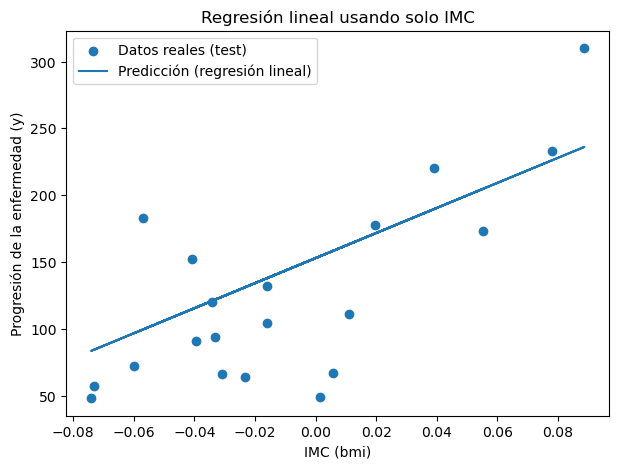

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(X_test, y_test, label="Datos reales (test)")
plt.plot(X_test, y_pred, label="Predicción (regresión lineal)")
plt.xlabel("IMC (bmi)")
plt.ylabel("Progresión de la enfermedad (y)")
plt.title("Regresión lineal usando solo IMC")
plt.legend()
plt.show()

Conclusion
El modelo de regresión lineal usando solo el IMC (bmi) logra explicar una parte moderada de la progresión de la diabetes (R² ≈ 0.47). Aunque la tendencia general se captura, el error cuadrático medio es relativamente alto (MSE ≈ 2548), lo que indica que bmi por sí solo no es suficiente para predecir con precisión y sería mejor incluir más variables del dataset para mejorar el desempeño.